In [1]:
# ========================================
# HYBRID RESNET-50 + ViT
# CELL 1: CEK DATASET
# ========================================

import os
from pathlib import Path

# Semua path project didefinisikan sekali dan dibuat relatif.
PROJECT_DIR = Path(".")
SOURCE_DIR = PROJECT_DIR / "dataset"
PREPROCESSED_DIR = PROJECT_DIR / "dataset_preprocessed"
SPLIT_DIR = PROJECT_DIR / "dataset_split"
BEST_MODEL_PATH = PROJECT_DIR / "hybrid_resnet_vit_best.pth"
CHECKPOINT_PATH = PROJECT_DIR / "hybrid_resnet_vit_checkpoint.pth"
TEST_DIR = SPLIT_DIR / "test"

VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".heic",
    ".heif"
)
print("CEK DATASET")
print("========================================")
print("HYBRID RESNET-50 + ViT")
print("========================================")
print("Folder :", SOURCE_DIR)
print("Isi    : penamaan seragam per kelas")
print("Resolusi target : 224 x 224")
print("========================================")

total = 0
jumlah_kelas = 0

if not os.path.exists(SOURCE_DIR):

    print("FOLDER TIDAK DITEMUKAN")

else:

    for class_name in sorted(
        os.listdir(SOURCE_DIR)
    ):

        class_path = os.path.join(
            SOURCE_DIR,
            class_name
        )

        if not os.path.isdir(class_path):
            continue

        jumlah = 0

        for root, dirs, files in os.walk(
            class_path
        ):

            for filename in files:

                if filename.lower().endswith(
                    VALID_EXTENSIONS
                ):
                    jumlah += 1

        jumlah_kelas += 1
        total += jumlah

        print(
            f"{class_name} : {jumlah} foto"
        )

print()
print("========================================")
print("HASIL PEMERIKSAAN")
print("========================================")

print(
    "Jumlah kelas :",
    jumlah_kelas
)

print(
    "Total foto   :",
    total
)

if jumlah_kelas == 10 and total >= 1200:

    print()
    print("DATASET")
    print("10 KELAS")
    print(f"{total} FOTO")

else:

    print()
    print("DATASET BELUM SESUAI")

print("========================================")

CEK DATASET
HYBRID RESNET-50 + ViT
Folder : dataset
Isi    : penamaan seragam per kelas
Resolusi target : 224 x 224
jahe : 741 foto
jahe merah : 230 foto
kencur : 741 foto
kunyit : 741 foto
kunyit putih : 347 foto
lempuyang : 541 foto
lengkuas : 741 foto
temu hitam : 237 foto
temu kunci : 541 foto
temulawak : 647 foto

HASIL PEMERIKSAAN
Jumlah kelas : 10
Total foto   : 5507

DATASET
10 KELAS
5507 FOTO


In [2]:
# ========================================
# HYBRID RESNET-50 + ViT
# BASELINE 100% - 224x224
# CELL 2: PREPROCESSING/
# ========================================

from PIL import Image
import os

OUTPUT_DIR = PREPROCESSED_DIR
IMAGE_SIZE = (224, 224)

VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".heic",
    ".heif"
)

print("========================================")
print("PREPROCESSING DATASET")
print("HYBRID RESNET-50 + ViT")
print("========================================")
print("Brightness : 100%")
print("Resize     : 224 x 224")
print("Input      :", SOURCE_DIR)
print("Output     :", OUTPUT_DIR)
print("========================================")

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

total_input = 0
total_output = 0
failed = 0

for class_name in sorted(
    os.listdir(SOURCE_DIR)
):

    class_path = os.path.join(
        SOURCE_DIR,
        class_name
    )

    if not os.path.isdir(class_path):
        continue

    output_class_path = os.path.join(
        OUTPUT_DIR,
        class_name
    )

    os.makedirs(
        output_class_path,
        exist_ok=True
    )

    count = 0

    print()
    print("Memproses:", class_name)

    for root, dirs, files in os.walk(
        class_path
    ):

        for filename in files:

            if not filename.lower().endswith(
                VALID_EXTENSIONS
            ):
                continue

            input_path = os.path.join(
                root,
                filename
            )

            try:

                total_input += 1

                with Image.open(
                    input_path
                ) as img:

                    # =================================
                    # TIDAK ADA PERUBAHAN BRIGHTNESS
                    # =================================

                    img = img.convert("RGB")

                    # =================================
                    # RESIZE 224 x 224
                    # =================================

                    img = img.resize(
                        IMAGE_SIZE,
                        Image.Resampling.LANCZOS
                    )

                    base_name = os.path.splitext(
                        filename
                    )[0]

                    output_name = (
                        base_name + ".jpg"
                    )

                    output_path = os.path.join(
                        output_class_path,
                        output_name
                    )

                    img.save(
                        output_path,
                        "JPEG",
                        quality=95
                    )

                    total_output += 1
                    count += 1

            except Exception as error:

                failed += 1

                print(
                    "Gagal:",
                    input_path
                )

                print(
                    "Error:",
                    error
                )

    print(
        "Jumlah    :",
        count,
        "foto"
    )

print()
print("========================================")
print("PREPROCESSING SELESAI")
print("========================================")

print(
    "Total gambar input  :",
    total_input
)

print(
    "Total gambar output :",
    total_output
)

print(
    "Gagal diproses      :",
    failed
)

print(
    "Brightness          :",
    "100% (ASLI / TIDAK DIUBAH)"
)

print(
    "Ukuran output       :",
    "224 x 224"
)

print(
    "Lokasi output       :",
    OUTPUT_DIR
)

print("========================================")

PREPROCESSING DATASET
HYBRID RESNET-50 + ViT
Brightness : 100%
Resize     : 224 x 224
Input      : dataset
Output     : dataset_preprocessed

Memproses: jahe
Jumlah    : 741 foto

Memproses: jahe merah
Jumlah    : 230 foto

Memproses: kencur
Jumlah    : 741 foto

Memproses: kunyit
Jumlah    : 741 foto

Memproses: kunyit putih
Jumlah    : 347 foto

Memproses: lempuyang
Jumlah    : 541 foto

Memproses: lengkuas
Jumlah    : 741 foto

Memproses: temu hitam
Jumlah    : 237 foto

Memproses: temu kunci
Jumlah    : 541 foto

Memproses: temulawak
Jumlah    : 647 foto

PREPROCESSING SELESAI
Total gambar input  : 5507
Total gambar output : 5507
Gagal diproses      : 0
Brightness          : 100% (ASLI / TIDAK DIUBAH)
Ukuran output       : 224 x 224
Lokasi output       : dataset_preprocessed


In [3]:
# ========================================
# HYBRID RESNET-50 + ViT
# CELL 3: VERIFIKASI RESOLUSI
# ========================================

from PIL import Image
import os

EXPECTED_SIZE = (224, 224)

total = 0
correct = 0
wrong = 0

print("========================================")
print("VERIFIKASI DATASET")
print("HYBRID RESNET-50 + ViT")
print("========================================")

for class_name in sorted(
    os.listdir(PREPROCESSED_DIR)
):

    class_path = os.path.join(
        PREPROCESSED_DIR,
        class_name
    )

    if not os.path.isdir(class_path):
        continue

    class_total = 0
    class_correct = 0
    class_wrong = 0

    for filename in os.listdir(class_path):

        file_path = os.path.join(
            class_path,
            filename
        )

        if not os.path.isfile(file_path):
            continue

        try:

            with Image.open(file_path) as img:

                total += 1
                class_total += 1

                if img.size == EXPECTED_SIZE:

                    correct += 1
                    class_correct += 1

                else:

                    wrong += 1
                    class_wrong += 1

        except Exception:

            wrong += 1
            class_wrong += 1

    print(
        f"{class_name} : "
        f"{class_total} foto | "
        f"benar {class_correct} | "
        f"salah {class_wrong}"
    )

print()
print("========================================")
print("HASIL VERIFIKASI")
print("========================================")

print("Total foto :", total)

print(
    "Ukuran yang diharapkan :",
    "224 x 224"
)

print(
    "Benar :", correct
)

print(
    "Salah :", wrong
)

if total > 0 and correct == total and wrong == 0:

    print()
    print(
        f"SEMUA {total} FOTO = 224 x 224"
    )

    print(
        "DATASET SIAP UNTUK SPLIT"
    )

else:

    print()
    print(
        "DATASET PERLU DIPERIKSA"
    )

print("========================================")

VERIFIKASI DATASET
HYBRID RESNET-50 + ViT
jahe : 741 foto | benar 741 | salah 0
jahe merah : 230 foto | benar 230 | salah 0
kencur : 741 foto | benar 741 | salah 0
kunyit : 741 foto | benar 741 | salah 0
kunyit putih : 347 foto | benar 347 | salah 0
lempuyang : 541 foto | benar 541 | salah 0
lengkuas : 741 foto | benar 741 | salah 0
temu hitam : 237 foto | benar 237 | salah 0
temu kunci : 541 foto | benar 541 | salah 0
temulawak : 647 foto | benar 647 | salah 0

HASIL VERIFIKASI
Total foto : 5507
Ukuran yang diharapkan : 224 x 224
Benar : 5507
Salah : 0

SEMUA 5507 FOTO = 224 x 224
DATASET SIAP UNTUK SPLIT


In [4]:
# ========================================
# HYBRID RESNET-50 + ViT
# CELL 4: SPLIT 70/15/15
# ========================================

import os
import shutil
import random

SPLIT_SOURCE_DIR = PREPROCESSED_DIR
SEED = 42

random.seed(SEED)

print("========================================")
print("SPLIT DATASET")
print("HYBRID RESNET-50 + ViT")
print("========================================")

print("Input :", SPLIT_SOURCE_DIR)
print("Output:", SPLIT_DIR)
print("Rasio : 70% / 15% / 15%")
print("Seed  :", SEED)
print("========================================")

# Split lama dihapus agar tidak ada sisa file usang.
if os.path.isdir(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

for split in ["train", "valid", "test"]:

    os.makedirs(
        os.path.join(
            SPLIT_DIR,
            split
        ),
        exist_ok=True
    )

total_train = 0
total_valid = 0
total_test = 0

for class_name in sorted(
    os.listdir(SPLIT_SOURCE_DIR)
):

    class_source = os.path.join(
        SPLIT_SOURCE_DIR,
        class_name
    )

    if not os.path.isdir(class_source):
        continue

    files = sorted(
        filename for filename in os.listdir(class_source)
        if os.path.isfile(
            os.path.join(
                class_source,
                filename
            )
        )
    )

    random.shuffle(files)

    train_target = round(len(files) * 0.70)
    valid_target = round(len(files) * 0.15)

    train_files = files[:train_target]

    valid_files = files[
        train_target:
        train_target + valid_target
    ]

    test_files = files[
        train_target + valid_target:
    ]

    for split in ["train", "valid", "test"]:

        os.makedirs(
            os.path.join(
                SPLIT_DIR,
                split,
                class_name
            ),
            exist_ok=True
        )

    for split, split_files in (
        ("train", train_files),
        ("valid", valid_files),
        ("test", test_files)
    ):

        for filename in split_files:

            shutil.copy2(
                os.path.join(
                    class_source,
                    filename
                ),
                os.path.join(
                    SPLIT_DIR,
                    split,
                    class_name,
                    filename
                )
            )

    total_train += len(train_files)
    total_valid += len(valid_files)
    total_test += len(test_files)

    print(
        f"{class_name} : "
        f"Train {len(train_files)} | "
        f"Valid {len(valid_files)} | "
        f"Test {len(test_files)}"
    )

print()
print("========================================")
print("SPLIT SELESAI")
print("========================================")

print(
    "Train :",
    total_train,
    "gambar"
)

print(
    "Valid :",
    total_valid,
    "gambar"
)

print(
    "Test  :",
    total_test,
    "gambar"
)

print(
    "Total :",
    total_train +
    total_valid +
    total_test,
    "gambar"
)

print(
    "Lokasi:",
    SPLIT_DIR
)

print("========================================")

SPLIT DATASET
HYBRID RESNET-50 + ViT
Input : dataset_preprocessed
Output: dataset_split
Rasio : 70% / 15% / 15%
Seed  : 42
jahe : Train 519 | Valid 111 | Test 111
jahe merah : Train 161 | Valid 34 | Test 35
kencur : Train 519 | Valid 111 | Test 111
kunyit : Train 519 | Valid 111 | Test 111
kunyit putih : Train 243 | Valid 52 | Test 52
lempuyang : Train 379 | Valid 81 | Test 81
lengkuas : Train 519 | Valid 111 | Test 111
temu hitam : Train 166 | Valid 36 | Test 35
temu kunci : Train 379 | Valid 81 | Test 81
temulawak : Train 453 | Valid 97 | Test 97

SPLIT SELESAI
Train : 3857 gambar
Valid : 825 gambar
Test  : 825 gambar
Total : 5507 gambar
Lokasi: dataset_split


In [5]:
# ========================================
# HYBRID RESNET-50 + ViT
# BASELINE 100% - 224x224
# CELL 5: CEK DUPLIKASI ANTAR SPLIT
# ========================================

import os
import hashlib

SPLITS = ["train", "valid", "test"]


def get_hash(file_path):

    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:

        for chunk in iter(
            lambda: file.read(1024 * 1024),
            b""
        ):

            sha256.update(chunk)

    return sha256.hexdigest()


print("========================================")
print("PEMERIKSAAN DUPLIKASI ANTAR SPLIT")
print("HYBRID RESNET-50 + ViT")
print("BRIGHTNESS 100% - 224x224")
print("========================================")

hashes = {}

# ========================================
# HITUNG HASH
# ========================================

for split in SPLITS:

    split_path = os.path.join(
        SPLIT_DIR,
        split
    )

    hashes[split] = set()

    for root, dirs, files in os.walk(
        split_path
    ):

        for filename in files:

            file_path = os.path.join(
                root,
                filename
            )

            try:

                file_hash = get_hash(
                    file_path
                )

                hashes[split].add(
                    file_hash
                )

            except Exception:

                print(
                    "Gagal membaca:",
                    file_path
                )

print()

for split in SPLITS:

    print(
        split.upper(),
        ":",
        len(hashes[split]),
        "hash unik"
    )

train_valid = (
    hashes["train"]
    &
    hashes["valid"]
)

train_test = (
    hashes["train"]
    &
    hashes["test"]
)

valid_test = (
    hashes["valid"]
    &
    hashes["test"]
)

print()
print("========================================")
print("HASIL PEMERIKSAAN")
print("========================================")

print(
    "TRAIN - VALID :",
    len(train_valid),
    "duplikasi"
)

print(
    "TRAIN - TEST  :",
    len(train_test),
    "duplikasi"
)

print(
    "VALID - TEST  :",
    len(valid_test),
    "duplikasi"
)

print()

if (
    len(train_valid) == 0
    and
    len(train_test) == 0
    and
    len(valid_test) == 0
):

    print(
        "TIDAK ADA DUPLIKASI ANTAR SPLIT"
    )

else:

    print(
        "DITEMUKAN DUPLIKASI ANTAR SPLIT"
    )

print("========================================")

PEMERIKSAAN DUPLIKASI ANTAR SPLIT
HYBRID RESNET-50 + ViT
BRIGHTNESS 100% - 224x224

TRAIN : 3857 hash unik
VALID : 825 hash unik
TEST : 825 hash unik

HASIL PEMERIKSAAN
TRAIN - VALID : 0 duplikasi
TRAIN - TEST  : 0 duplikasi
VALID - TEST  : 0 duplikasi

TIDAK ADA DUPLIKASI ANTAR SPLIT


In [6]:
# ========================================
# HYBRID RESNET-50 + ViT
# BASELINE 100% - 224x224
# CELL 6: DATALOADER
# ========================================

import os

# Batasi thread CPU sebelum PyTorch/BLAS diimpor.
CPU_THREADS = min(4, os.cpu_count() or 1)

for variable in (
    "OMP_NUM_THREADS",
    "MKL_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "NUMEXPR_NUM_THREADS"
):
    os.environ[variable] = str(CPU_THREADS)

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

torch.set_num_threads(CPU_THREADS)

try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    # Inter-op hanya dapat diatur sekali dalam satu sesi kernel.
    pass

BATCH_SIZE = 8
NUM_WORKERS = 0

if torch.cuda.is_available():
    gpu_free_memory = [
        torch.cuda.mem_get_info(index)[0]
        for index in range(torch.cuda.device_count())
    ]
    GPU_INDEX = max(
        range(torch.cuda.device_count()),
        key=gpu_free_memory.__getitem__
    )
    DEVICE = torch.device(f"cuda:{GPU_INDEX}")
else:
    GPU_INDEX = None
    gpu_free_memory = []
    DEVICE = torch.device("cpu")

# ======================================================
# DATA AUGMENTATION UNTUK FOTO DUNIA NYATA
# - Crop lebih ekstrem  : objek kecil di tengah frame
# - GaussianBlur        : foto kurang fokus
# - RandomErasing       : oklusi tanah/daun/tangan
# ======================================================

train_transform = transforms.Compose([

    transforms.Resize((256, 256)),

    transforms.RandomResizedCrop(
        224,
        scale=(0.60, 1.00)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(25),

    transforms.ColorJitter(
        brightness=0.40,
        contrast=0.40,
        saturation=0.30,
        hue=0.06
    ),

    transforms.RandomAffine(
        degrees=10,
        translate=(0.12, 0.12)
    ),

    transforms.RandomApply(
        [
            transforms.GaussianBlur(
                kernel_size=3,
                sigma=(0.1, 1.5)
            )
        ],
        p=0.25
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

    transforms.RandomErasing(
        p=0.25,
        scale=(0.02, 0.12),
        value="random"
    )

])

transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])

train_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_DIR, "train"),
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_DIR, "valid"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_DIR, "test"),
    transform=transform
)

pin_memory = DEVICE.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print("========================================")
print("DATALOADER HYBRID RESNET-50 + ViT")
print("BASELINE 100% - 224x224")
print("========================================")
print("Device              :", DEVICE)

if DEVICE.type == "cuda":
    print("GPU index           :", GPU_INDEX)
    print("GPU name            :", torch.cuda.get_device_name(GPU_INDEX))
    print(
        "GPU free awal (GB) :",
        f"{gpu_free_memory[GPU_INDEX] / 1024**3:.2f}"
    )

print("Thread CPU intra-op :", torch.get_num_threads())
print("Thread CPU inter-op :", torch.get_num_interop_threads())
print("Worker DataLoader   :", NUM_WORKERS)
print()
print("Train :", len(train_dataset), "gambar")
print("Valid :", len(valid_dataset), "gambar")
print("Test  :", len(test_dataset), "gambar")
print()
print("Batch size    :", BATCH_SIZE)
print("Jumlah kelas  :", NUM_CLASSES)
print()
print("Augmentasi    : crop 0.60-1.0 | blur p=0.25 | erasing p=0.25")
print()
print("Kelas:")

for index, name in enumerate(CLASS_NAMES):
    print(f"{index}: {name}")

print("========================================")

DATALOADER HYBRID RESNET-50 + ViT
BASELINE 100% - 224x224
Device              : cuda:1
GPU index           : 1
GPU name            : NVIDIA L40S
GPU free awal (GB) : 38.77
Thread CPU intra-op : 4
Thread CPU inter-op : 1
Worker DataLoader   : 0

Train : 3857 gambar
Valid : 825 gambar
Test  : 825 gambar

Batch size    : 8
Jumlah kelas  : 10

Augmentasi    : crop 0.60-1.0 | blur p=0.25 | erasing p=0.25

Kelas:
0: jahe
1: jahe merah
2: kencur
3: kunyit
4: kunyit putih
5: lempuyang
6: lengkuas
7: temu hitam
8: temu kunci
9: temulawak


In [7]:
# ========================================
# HYBRID RESNET-50 + ViT
# BASELINE 100% — 224x224
# CELL 7: MODEL
# ========================================

import torch
import torch.nn as nn

from torchvision.models import (
    resnet50,
    ResNet50_Weights,
    vit_b_16,
    ViT_B_16_Weights
)

print("========================================")
print("MEMBUAT MODEL HYBRID")
print("RESNET-50 + ViT-B/16")
print("BASELINE 100% — 224x224")
print("========================================")

# ========================================
# RESNET-50
# ========================================

resnet_baseline = resnet50(
    weights=ResNet50_Weights.IMAGENET1K_V2
)

# Hapus classifier bawaan
resnet_baseline.fc = nn.Identity()

# ========================================
# ViT-B/16
# ========================================

vit_baseline = vit_b_16(
    weights=ViT_B_16_Weights.IMAGENET1K_V1
)

# Hapus classifier bawaan
vit_baseline.heads = nn.Identity()

# ========================================
# UKURAN FITUR
# ========================================

RESNET_FEATURES = 2048
VIT_FEATURES = 768

FUSION_FEATURES = (
    RESNET_FEATURES +
    VIT_FEATURES
)

# ========================================
# MODEL HYBRID
# ========================================

class HybridResNetViTBaseline(nn.Module):

    def __init__(
        self,
        resnet,
        vit,
        num_classes
    ):

        super().__init__()

        self.resnet = resnet
        self.vit = vit

        self.classifier = nn.Sequential(

            nn.Linear(
                FUSION_FEATURES,
                512
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                512,
                num_classes
            )
        )

    def forward(self, x):

        # Fitur ResNet-50
        resnet_features = self.resnet(x)

        # Fitur ViT
        vit_features = self.vit(x)

        # Feature Fusion
        combined = torch.cat(
            (
                resnet_features,
                vit_features
            ),
            dim=1
        )

        # Classification
        output = self.classifier(
            combined
        )

        return output


# ========================================
# INSTANCE MODEL
# ========================================

model_baseline = HybridResNetViTBaseline(
    resnet_baseline,
    vit_baseline,
    NUM_CLASSES
)

model_baseline = model_baseline.to(
    DEVICE
)

print()
print("========================================")
print("MODEL BASELINE SIAP")
print("========================================")

print(
    "Architecture : Hybrid ResNet-50 + ViT-B/16"
)

print(
    "ResNet features :",
    RESNET_FEATURES
)

print(
    "ViT features    :",
    VIT_FEATURES
)

print(
    "Fusion features :",
    FUSION_FEATURES
)

print(
    "Jumlah kelas    :",
    NUM_CLASSES
)

print(
    "Device          :",
    DEVICE
)

print("========================================")

MEMBUAT MODEL HYBRID
RESNET-50 + ViT-B/16
BASELINE 100% — 224x224

MODEL BASELINE SIAP
Architecture : Hybrid ResNet-50 + ViT-B/16
ResNet features : 2048
ViT features    : 768
Fusion features : 2816
Jumlah kelas    : 10
Device          : cuda:1


In [8]:
# ========================================
# HYBRID RESNET-50 + ViT
# CELL 8: KONFIGURASI TRAINING
# ========================================

import torch.nn as nn
import torch.optim as optim

print("========================================")
print("KONFIGURASI TRAINING HYBRID")
print("DATASET")
print("========================================")

LEARNING_RATE = 0.0001
BACKBONE_LEARNING_RATE = 0.00001
WEIGHT_DECAY = 0.0001
BATCH_SIZE = train_loader.batch_size
EPOCHS = 15
DROPOUT = 0.3

print("LR classifier :", LEARNING_RATE)
print("LR backbone   :", BACKBONE_LEARNING_RATE)
print("Weight decay  :", WEIGHT_DECAY)
print("Batch size    :", BATCH_SIZE)
print("Epoch         :", EPOCHS)
print("Dropout       :", DROPOUT)

# ========================================
# FREEZE SEMUA, LALU BUKA BAGIAN AKHIR
# ========================================

for param in model_baseline.parameters():
    param.requires_grad = False

for param in model_baseline.resnet.layer3.parameters():
    param.requires_grad = True

for param in model_baseline.resnet.layer4.parameters():
    param.requires_grad = True

for param in model_baseline.vit.encoder.layers[-2].parameters():
    param.requires_grad = True

for param in model_baseline.vit.encoder.layers[-1].parameters():
    param.requires_grad = True

for param in model_baseline.classifier.parameters():
    param.requires_grad = True

# ========================================
# LOSS FUNCTION
# ========================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

# ========================================
# OPTIMIZER (LEARNING RATE BERTINGKAT)
# ========================================

optimizer = optim.AdamW(
    [
        {
            "params": model_baseline.classifier.parameters(),
            "lr": LEARNING_RATE
        },
        {
            "params": model_baseline.resnet.layer3.parameters(),
            "lr": BACKBONE_LEARNING_RATE
        },
        {
            "params": model_baseline.resnet.layer4.parameters(),
            "lr": BACKBONE_LEARNING_RATE
        },
        {
            "params": model_baseline.vit.encoder.layers[-2].parameters(),
            "lr": BACKBONE_LEARNING_RATE
        },
        {
            "params": model_baseline.vit.encoder.layers[-1].parameters(),
            "lr": BACKBONE_LEARNING_RATE
        }
    ],
    weight_decay=WEIGHT_DECAY
)

# ========================================
# SCHEDULER
# ========================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

print()
print("========================================")
print("KONFIGURASI SIAP")
print("========================================")

print("ResNet-50        : Frozen kecuali layer3 + layer4")
print("ViT-B/16         : Frozen kecuali 2 blok terakhir")
print("Classifier       : Trainable")
print("Label smoothing  : 0.1")

print("========================================")

KONFIGURASI TRAINING HYBRID
DATASET
LR classifier : 0.0001
LR backbone   : 1e-05
Weight decay  : 0.0001
Batch size    : 8
Epoch         : 15
Dropout       : 0.3

KONFIGURASI SIAP
ResNet-50        : Frozen kecuali layer3 + layer4
ViT-B/16         : Frozen kecuali 2 blok terakhir
Classifier       : Trainable
Label smoothing  : 0.1


In [9]:
# ========================================
# HYBRID RESNET-50 + ViT
# BASELINE 100% - 224x224
# CELL 9: TRAINING
# ========================================

import time
import copy
import torch

print("========================================")
print("TRAINING HYBRID RESNET-50 + ViT")
print("BASELINE")
print("BRIGHTNESS : 100%")
print("RESOLUSI   : 224 x 224")
print("========================================")

best_val_acc = 0.0
best_epoch = 0
best_model_state = None

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

start_time = time.time()

# ========================================
# TRAINING LOOP
# ========================================

for epoch in range(EPOCHS):

    # ------------------------------------
    # TRAIN
    # ------------------------------------

    model_baseline.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model_baseline(
            images
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() *
            images.size(0)
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    train_loss = (
        running_loss / total
    )

    train_acc = (
        correct / total
    ) * 100

    # ------------------------------------
    # VALIDATION
    # ------------------------------------

    model_baseline.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            outputs = model_baseline(
                images
            )

            loss = criterion(
                outputs,
                labels
            )

            val_running_loss += (
                loss.item() *
                images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_loss = (
        val_running_loss /
        val_total
    )

    val_acc = (
        val_correct /
        val_total
    ) * 100

    history["train_loss"].append(
        train_loss
    )

    history["train_acc"].append(
        train_acc
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_acc"].append(
        val_acc
    )

    scheduler.step(
        val_loss
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model_baseline.state_dict()
        )

        torch.save(
            best_model_state,
            BEST_MODEL_PATH
        )

        best_message = (
            "Model terbaik disimpan."
        )

    else:

        best_message = ""

    checkpoint = {
        "epoch": epoch + 1,
        "model_state_dict":
            model_baseline.state_dict(),
        "optimizer_state_dict":
            optimizer.state_dict(),
        "scheduler_state_dict":
            scheduler.state_dict(),
        "best_val_acc":
            best_val_acc,
        "best_epoch":
            best_epoch,
        "history":
            history
    }

    torch.save(
        checkpoint,
        CHECKPOINT_PATH
    )

    if best_message:
        print(best_message)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}]"
    )

    print("----------------------------------------")

    print(
        f"Train Loss : {train_loss:.4f}"
    )

    print(
        f"Train Acc  : {train_acc:.2f}%"
    )

    print(
        f"Val Loss   : {val_loss:.4f}"
    )

    print(
        f"Val Acc    : {val_acc:.2f}%"
    )

    print("Checkpoint tersimpan.")

if best_model_state is not None:

    model_baseline.load_state_dict(
        best_model_state
    )

training_time = (
    time.time() - start_time
) / 60

print()
print("========================================")
print("TRAINING BASELINE SELESAI")
print("========================================")

print(
    f"Best Epoch          : "
    f"{best_epoch}"
)

print(
    f"Best Validation Acc : "
    f"{best_val_acc:.2f}%"
)

print(
    f"Waktu Training      : "
    f"{training_time:.2f} menit"
)

print(
    "Model terbaik      :",
    BEST_MODEL_PATH
)

print(
    "Checkpoint          :",
    CHECKPOINT_PATH
)

print("========================================")

TRAINING HYBRID RESNET-50 + ViT
BASELINE
BRIGHTNESS : 100%
RESOLUSI   : 224 x 224
Model terbaik disimpan.
Epoch [1/15]
----------------------------------------
Train Loss : 1.3413
Train Acc  : 67.64%
Val Loss   : 0.9351
Val Acc    : 84.73%
Checkpoint tersimpan.
Model terbaik disimpan.
Epoch [2/15]
----------------------------------------
Train Loss : 0.8735
Train Acc  : 86.62%
Val Loss   : 0.8022
Val Acc    : 90.55%
Checkpoint tersimpan.
Model terbaik disimpan.
Epoch [3/15]
----------------------------------------
Train Loss : 0.7655
Train Acc  : 91.73%
Val Loss   : 0.7520
Val Acc    : 92.61%
Checkpoint tersimpan.
Model terbaik disimpan.
Epoch [4/15]
----------------------------------------
Train Loss : 0.7259
Train Acc  : 93.83%
Val Loss   : 0.7118
Val Acc    : 94.18%
Checkpoint tersimpan.
Model terbaik disimpan.
Epoch [5/15]
----------------------------------------
Train Loss : 0.6832
Train Acc  : 95.67%
Val Loss   : 0.6870
Val Acc    : 95.03%
Checkpoint tersimpan.
Model terbaik disi

In [10]:
# ========================================
# HYBRID RESNET-50 + ViT
# BASELINE 100% - 224x224
# CELL 10: EVALUASI TEST
# ========================================

import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("========================================")
print("EVALUASI TEST - HYBRID RESNET-50 + ViT")
print("BASELINE")
print("BRIGHTNESS : 100%")
print("RESOLUSI   : 224 x 224")
print("========================================")

# ========================================
# LOAD MODEL TERBAIK
# ========================================

model_baseline.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE
    )
)

model_baseline = model_baseline.to(
    DEVICE
)

model_baseline.eval()

# ========================================
# PREDIKSI TEST
# ========================================

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        outputs = model_baseline(
            images
        )

        _, predictions = torch.max(
            outputs,
            1
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

# ========================================
# ACCURACY
# ========================================

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

labels_array = np.array(all_labels)
predictions_array = np.array(all_predictions)

correct = np.sum(
    labels_array == predictions_array
)

total = len(all_labels)

wrong = total - correct

print()
print("========================================")
print("HASIL TEST BASELINE")
print("========================================")

print(
    f"Test Accuracy : "
    f"{accuracy * 100:.2f}%"
)

print(
    "Jumlah data   :",
    total
)

print(
    "Prediksi benar :",
    correct
)

print(
    "Prediksi salah :",
    wrong
)

# ========================================
# CLASSIFICATION REPORT
# ========================================

print()
print("========================================")
print("CLASSIFICATION REPORT")
print("========================================")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=CLASS_NAMES,
        digits=4
    )
)

# ========================================
# CONFUSION MATRIX
# ========================================

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print()
print("========================================")
print("CONFUSION MATRIX")
print("========================================")

print(cm)

print()
print("========================================")
print("EVALUASI BASELINE SELESAI")
print("========================================")

EVALUASI TEST - HYBRID RESNET-50 + ViT
BASELINE
BRIGHTNESS : 100%
RESOLUSI   : 224 x 224

HASIL TEST BASELINE
Test Accuracy : 98.06%
Jumlah data   : 825
Prediksi benar : 809
Prediksi salah : 16

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        jahe     0.9316    0.9820    0.9561       111
  jahe merah     1.0000    0.9714    0.9855        35
      kencur     0.9905    0.9369    0.9630       111
      kunyit     1.0000    0.9820    0.9909       111
kunyit putih     1.0000    0.9615    0.9804        52
   lempuyang     0.9875    0.9753    0.9814        81
    lengkuas     0.9911    1.0000    0.9955       111
  temu hitam     0.9459    1.0000    0.9722        35
  temu kunci     0.9878    1.0000    0.9939        81
   temulawak     0.9798    1.0000    0.9898        97

    accuracy                         0.9806       825
   macro avg     0.9814    0.9809    0.9809       825
weighted avg     0.9812    0.9806    0.9806       825


CONFUSION MATRIX
[[109 

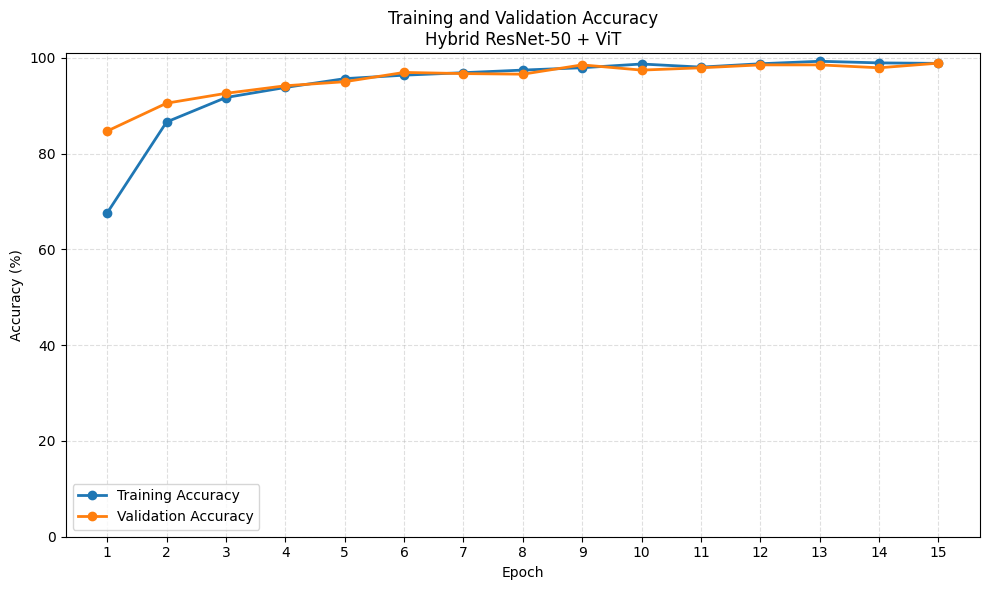

In [11]:
# ========================================
# GRAFIK ACCURACY
# HYBRID RESNET-50 + ViT
# BRIGHTNESS 100% - 224x224
# ========================================

import matplotlib.pyplot as plt

epochs = list(range(1, len(history["train_acc"]) + 1))
train_accuracy = history["train_acc"]
val_accuracy = history["val_acc"]

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    train_accuracy,
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracy,
    marker="o",
    linewidth=2,
    label="Validation Accuracy"
)

plt.title(
    "Training and Validation Accuracy\n"
    "Hybrid ResNet-50 + ViT"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(epochs)
plt.ylim(0, 101)

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.legend()
plt.tight_layout()
plt.show()

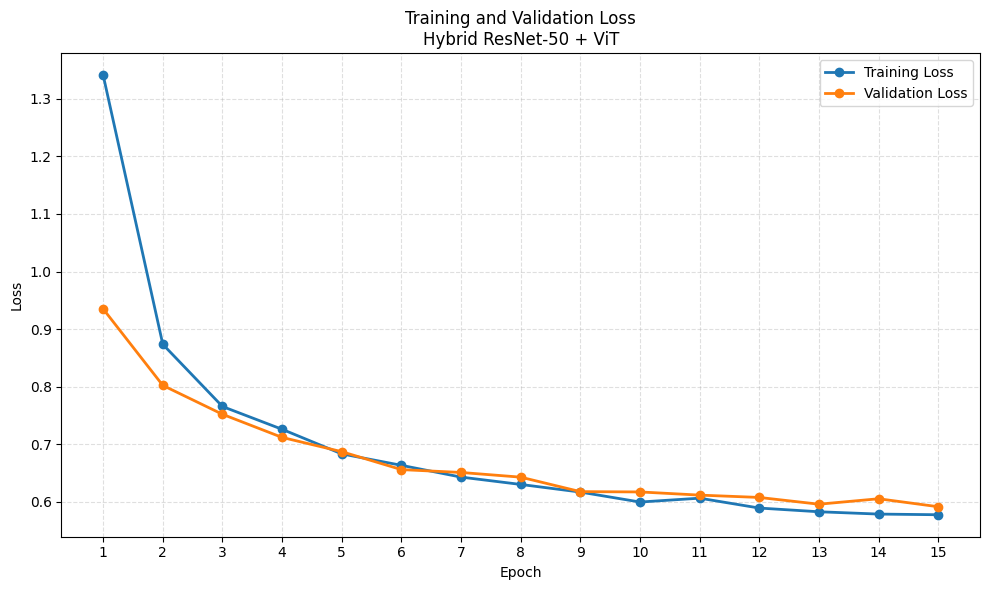

In [12]:
# ========================================
# GRAFIK LOSS
# HYBRID RESNET-50 + ViT
# BRIGHTNESS 100% - 224x224
# ========================================

import matplotlib.pyplot as plt

epochs = list(range(1, len(history["train_loss"]) + 1))
train_loss = history["train_loss"]
val_loss = history["val_loss"]

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    train_loss,
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.title(
    "Training and Validation Loss\n"
    "Hybrid ResNet-50 + ViT"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.legend()
plt.tight_layout()
plt.show()

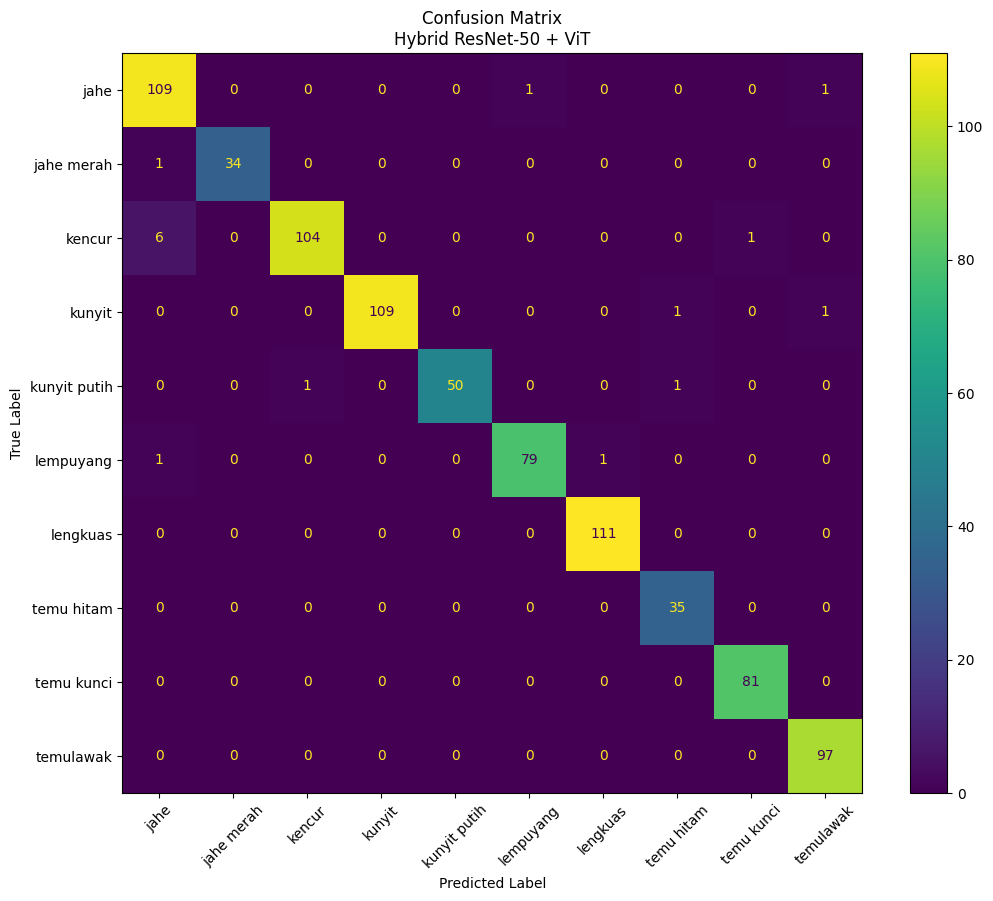

In [13]:
# ========================================
# CONFUSION MATRIX
# HYBRID RESNET-50 + ViT
# BRIGHTNESS 100% — 224x224
# ========================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    all_labels,
    all_predictions
)

fig, ax = plt.subplots(
    figsize=(11, 9)
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

display.plot(
    ax=ax,
    xticks_rotation=45,
    values_format='d'
)

plt.title(
    'Confusion Matrix\n'
    'Hybrid ResNet-50 + ViT'
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()

plt.show()

JUMLAH GAMBAR SALAH : 16
1. Asli      : jahe
   Prediksi  : lempuyang
   Confidence: 49.99%
   File      : jahe_239.jpg
------------------------------------------------------------
2. Asli      : jahe
   Prediksi  : temulawak
   Confidence: 46.06%
   File      : jahe_388.jpg
------------------------------------------------------------
3. Asli      : jahe merah
   Prediksi  : jahe
   Confidence: 72.99%
   File      : jahe_merah_207.jpg
------------------------------------------------------------
4. Asli      : kencur
   Prediksi  : jahe
   Confidence: 38.92%
   File      : kencur_418.jpg
------------------------------------------------------------
5. Asli      : kencur
   Prediksi  : jahe
   Confidence: 44.84%
   File      : kencur_338.jpg
------------------------------------------------------------
6. Asli      : kencur
   Prediksi  : jahe
   Confidence: 39.83%
   File      : kencur_513.jpg
------------------------------------------------------------
7. Asli      : kencur
   Prediksi  

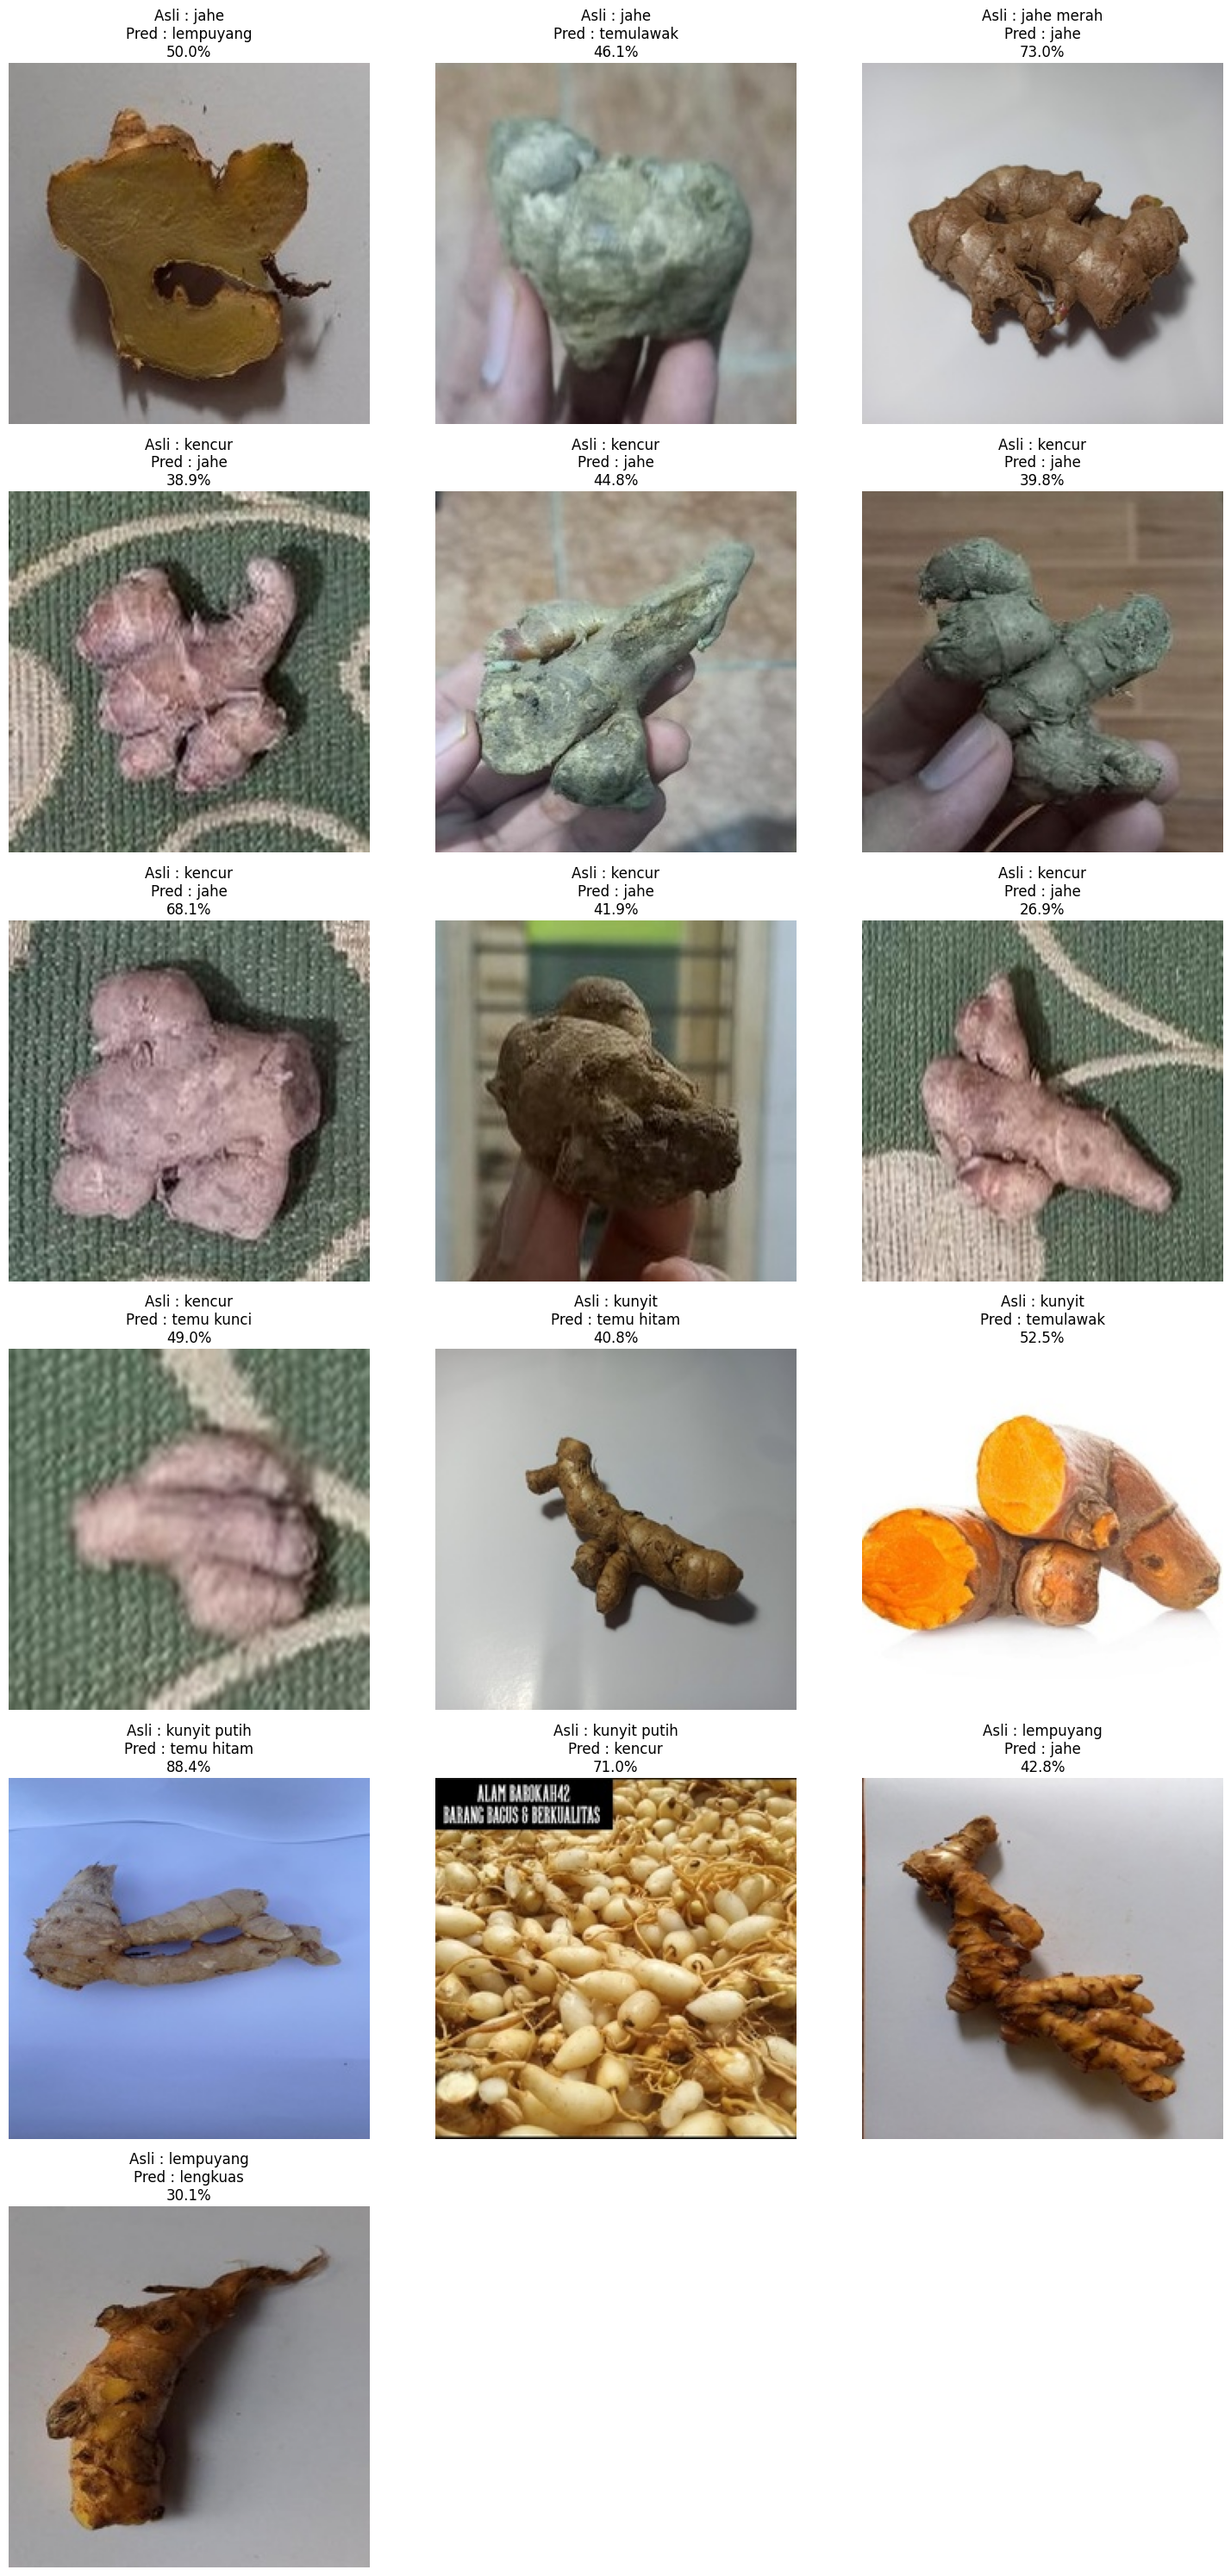

In [14]:
# ========================================
# HYBRID RESNET-50 + ViT
# BASELINE 100% - 224x224
# CELL 11: TAMPILKAN SEMUA GAMBAR SALAH
# ========================================

import os
import torch
import matplotlib.pyplot as plt
from PIL import Image

# ----------------------------------------
# LOAD MODEL TERBAIK
# ----------------------------------------

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

model_baseline.load_state_dict(checkpoint)
model_baseline.to(DEVICE)
model_baseline.eval()

# Transform sama dengan evaluasi test
transform_check = transform

# ----------------------------------------
# CARI SEMUA GAMBAR YANG SALAH
# ----------------------------------------

wrong_predictions = []

for true_class in CLASS_NAMES:

    class_path = os.path.join(TEST_DIR, true_class)

    if not os.path.exists(class_path):
        print(f"Folder tidak ditemukan : {class_path}")
        continue

    for filename in os.listdir(class_path):

        file_path = os.path.join(class_path, filename)

        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        image = Image.open(file_path).convert("RGB")

        image_tensor = transform_check(image).unsqueeze(0).to(DEVICE)

        with torch.no_grad():

            output = model_baseline(image_tensor)

            probabilities = torch.softmax(output, dim=1)

            pred_index = torch.argmax(probabilities, dim=1).item()

            pred_class = CLASS_NAMES[pred_index]

            confidence = probabilities[0][pred_index].item() * 100

        # Simpan jika SALAH
        if pred_class != true_class:

            wrong_predictions.append({
                "true": true_class,
                "pred": pred_class,
                "confidence": confidence,
                "file": file_path
            })

# ----------------------------------------
# HASIL
# ----------------------------------------

print("=" * 60)
print("JUMLAH GAMBAR SALAH :", len(wrong_predictions))
print("=" * 60)

for index, item in enumerate(wrong_predictions, start=1):

    print(f"{index}. Asli      : {item['true']}")
    print(f"   Prediksi  : {item['pred']}")
    print(f"   Confidence: {item['confidence']:.2f}%")
    print(f"   File      : {os.path.basename(item['file'])}")
    print("-" * 60)

# ----------------------------------------
# TAMPILKAN SEMUA GAMBAR SALAH
# ----------------------------------------

cols = 3
rows = (len(wrong_predictions) + cols - 1) // cols

if wrong_predictions:
    plt.figure(figsize=(15, rows * 5))

    for index, item in enumerate(wrong_predictions):

        plt.subplot(rows, cols, index + 1)

        image = Image.open(item["file"]).convert("RGB")

        plt.imshow(image)

        plt.title(
            f"Asli : {item['true']}\n"
            f"Pred : {item['pred']}\n"
            f"{item['confidence']:.1f}%"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada gambar yang salah diprediksi.")

In [15]:
# ========================================
# TABEL RINGKASAN HASIL BASELINE
# HYBRID RESNET-50 + ViT
# BRIGHTNESS 100% - 224x224
# ========================================

import pandas as pd
from sklearn.metrics import classification_report

report_data = classification_report(
    all_labels,
    all_predictions,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

macro_average = report_data["macro avg"]
dataset_total = (
    len(train_dataset)
    + len(valid_dataset)
    + len(test_dataset)
)

hasil_baseline = pd.DataFrame({
    "Parameter": [
        "Model",
        "Brightness",
        "Resolusi",
        "Jumlah Kelas",
        "Dataset",
        "Data Training",
        "Data Validation",
        "Data Testing",
        "Epoch",
        "Best Epoch",
        "Best Validation Accuracy",
        "Test Accuracy",
        "Prediksi Benar",
        "Prediksi Salah",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-Score"
    ],
    "Hasil": [
        "Hybrid ResNet-50 + ViT",
        "100%",
        "224 x 224",
        str(NUM_CLASSES),
        f"{dataset_total} gambar",
        f"{len(train_dataset)} gambar",
        f"{len(valid_dataset)} gambar",
        f"{len(test_dataset)} gambar",
        str(len(history["train_loss"])),
        str(best_epoch),
        f"{best_val_acc:.2f}%",
        f"{accuracy * 100:.2f}%",
        f"{correct} / {total}",
        f"{wrong} / {total}",
        f"{macro_average['precision'] * 100:.2f}%",
        f"{macro_average['recall'] * 100:.2f}%",
        f"{macro_average['f1-score'] * 100:.2f}%"
    ]
})

hasil_baseline

,Parameter,Hasil
0,Model,Hybrid ResNet-50 + ViT
1,Brightness,100%
2,Resolusi,224 x 224
3,Jumlah Kelas,10
4,Dataset,5507 gambar
5,Data Training,3857 gambar
6,Data Validation,825 gambar
7,Data Testing,825 gambar
8,Epoch,15
9,Best Epoch,15
